In [76]:
!rm -rf clone && git clone https://github.com/pui-sum-rv/lab5 clone && cp -a clone/. .

Cloning into 'clone'...
remote: Enumerating objects: 17, done.
remote: Counting objects: 100% (17/17), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 17 (delta 3), reused 11 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (17/17), 152.42 KiB | 5.25 MiB/s, done.
Resolving deltas: 100% (3/3), done.


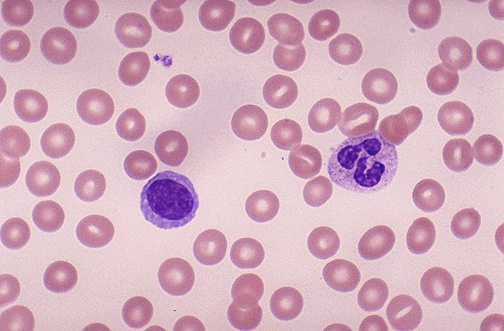

In [77]:
import numpy as np
import cv2 as cv
from google.colab.patches import cv2_imshow
import random as rng
import os

path = 'images/cells.jpg'

img = cv.imread(path)
cv2_imshow(img)

In [78]:
# Gray

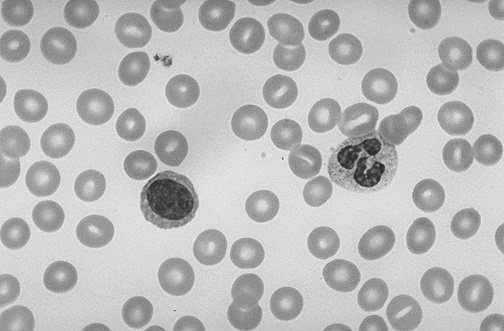

In [79]:
gray_img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
cv2_imshow(gray_img)

In [80]:
# CLAHE

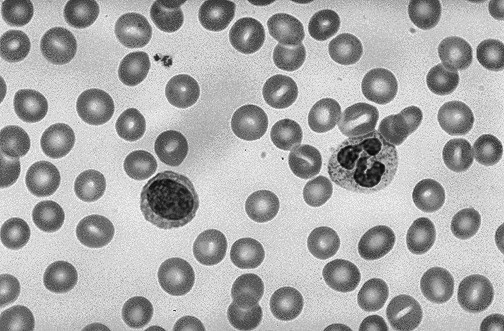

In [81]:
contrast = cv.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
# enhanced = contrast.apply(gray_img)

cv2_imshow(enhanced)

In [82]:
# OTSU

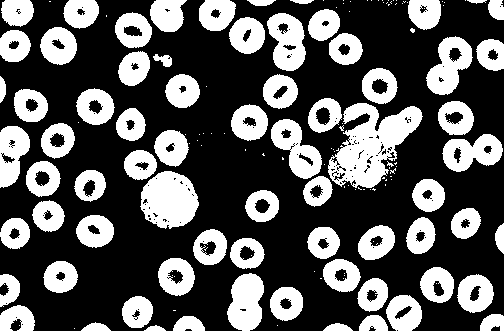

In [83]:
_, binary = cv.threshold(
    enhanced, 0, 255,
    cv.THRESH_BINARY_INV + cv.THRESH_OTSU
)

cv2_imshow(binary)

In [84]:
# Morfologija

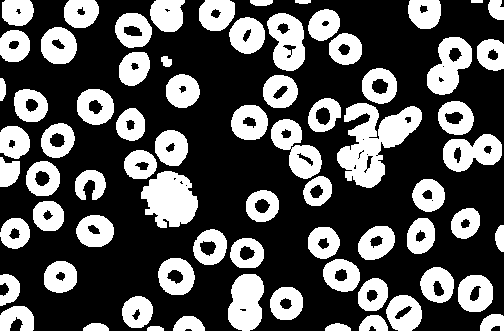

In [85]:
struct = np.ones((3, 3), np.uint8)

cleaned = cv.morphologyEx(binary, cv.MORPH_OPEN, struct, iterations=2)

cv2_imshow(cleaned)

In [86]:
# Sigurna zona

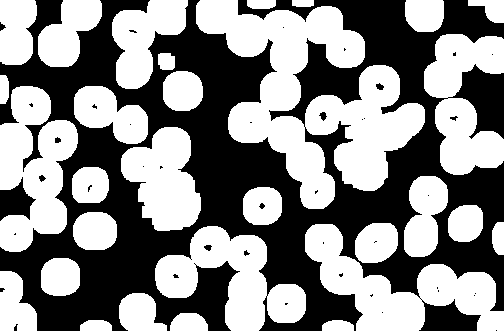

In [87]:
background = cv.dilate(cleaned, struct, iterations=3)

cv2_imshow(background)

In [88]:
# Distance transform

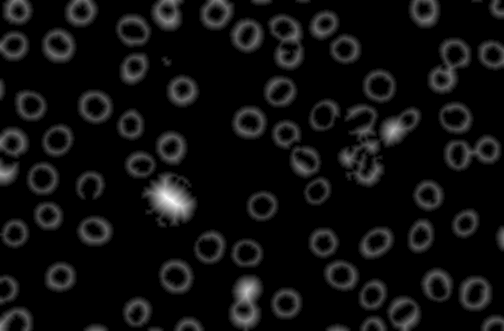

In [89]:
distance_map = cv.distanceTransform(cleaned, cv.DIST_L2, 3)
cv.normalize(distance_map, distance_map, 0, 1.0, cv.NORM_MINMAX)

cv2_imshow(distance_map * 255)

In [90]:
# Jezgro

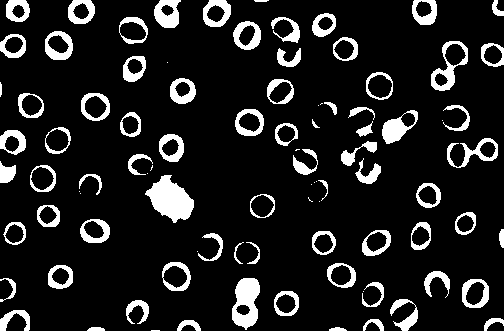

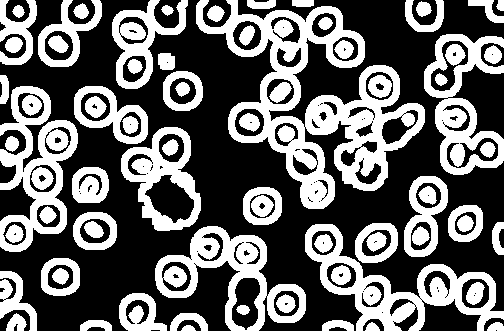

In [91]:
_, foreground = cv.threshold(distance_map, 0.2 * distance_map.max(), 255, 0)
foreground = np.uint8(foreground)

boundary = cv.subtract(background, foreground)

cv2_imshow(foreground)
cv2_imshow(boundary)

In [92]:
# Kreiranje markera

In [93]:
_, labels = cv.connectedComponents(foreground)

labels = labels + 1
labels[boundary == 255] = 0

In [94]:
# Watershed

In [95]:
labels = cv.watershed(img, labels)

In [96]:
# Vizualizacija rezultata

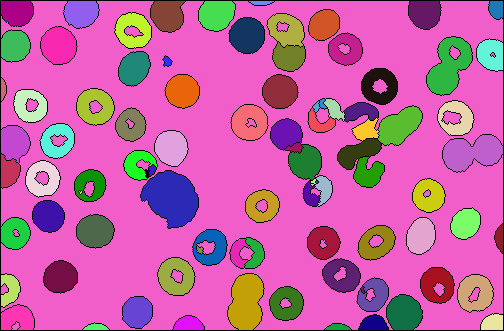

In [97]:
output = np.zeros_like(img)

palette = []
for i in range(labels.max() + 1):
    palette.append((rng.randint(0,255), rng.randint(0,255), rng.randint(0,255)))

for y in range(labels.shape[0]):
    for x in range(labels.shape[1]):
        val = labels[y, x]
        if val > 0:
            output[y, x] = palette[val]

cv2_imshow(output)

In [98]:
# Spremanje

In [99]:
cv.imwrite("images/result.png", output)

True

In [100]:
from google.colab import files
uploaded = files.upload()

Saving annotated.png to annotated (2).png


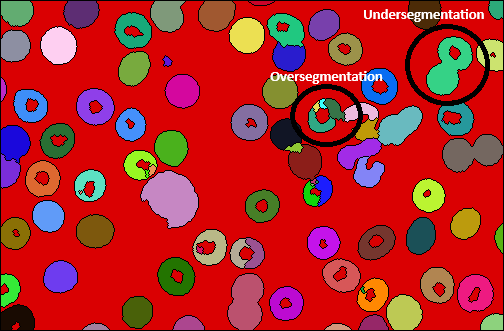

In [101]:
from google.colab.patches import cv2_imshow

filename = list(uploaded.keys())[0]
img = cv.imread(filename)
cv2_imshow(img)

In [103]:
# Annotated image shows one example of oversegmentation (single cell split into multiple regions) and one example of undersegmentation (multiple cells merged into one region).

In [104]:
# Komentar

In [105]:
# Primjenom CLAHE metode pojačava se lokalni kontrast između krvnih stanica i pozadine, što rezultira jasnijim prikazom rubova stanica.
# Zbog toga su pragiranje i watershed segmentacija učinkovitiji te dolazi do boljeg razdvajanja pojedinih stanica.

# U slučaju kada CLAHE nije primijenjen, kontrast slike je slabiji pa su granice između stanica manje izražene.
# To otežava segmentaciju i često dovodi do toga da su neke stanice spojene ili se teže razlikuju jedna od druge.
#